Como fazer upload de arquivos:


1.   Clique na pastinha na barra a esquerda ("Arquivos)
2.   Espere conectar ao ambiente
3.   Clique no arquivo com uma seta para cima ("Fazer upload para armazenamento da sessão)
4.   Faça o upload

Obs.: Você deve fazer upload todas as vezes que entrar no colab

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import sympy as sp

#Eu podia ter importando 1 vez mas não fiz
import scipy as cp
from scipy import stats
from scipy.fft import fft, ifft , fftfreq
from scipy.signal import find_peaks
from scipy.integrate import odeint

import pandas as pd
import wave
import struct

In [ ]:
#Alguem pode pesquisar sobre erro padrao e ver se podemos dividir por raiz de n
def Desvio_padra (lista):
  #Desvio padrão de amostra
    media = sum(lista)/len(lista)
    Somatoria = 0
    for i in lista:
        Somatoria += (i - media)**2
    desvio = (Somatoria/(len(lista) -1 ))**0.5
    return desvio

In [ ]:
def Erro_padrao(lista):
    media = sum(lista)/len(lista)
    Somatoria = 0
    for i in lista:
        Somatoria += (i - media)**2
    desvio = (Somatoria/(len(lista) -1 ))**0.5/np.sqrt(len(lista))
    return  media, desvio

In [ ]:
def grau_radiano(grau):
  #trasforma de graus para radiano
  return (grau * np.pi)/180

def radiano_grau(radiano):
  #trasforma de radiano para graus
  return (radiano * 180)/np.pi

In [ ]:
#Globais:
g = 9.783816

###Cálculo de incerteza por derivada parcial

Como funciona: Essa função vai receber os parâmentros e calcular a incerteza por derivadas parciais

Parâmetros:

        equacao_str (str): Equação como string,lembre de escreve-la como fazia no sympy (sem .np ou .sp) (ex.: "a = sqrt(l * b/ pi)")

        variaveis_dict (dict): Valores numéricos das variáveis  (ex:{"l": 10, "b": 2})

        incertezas_dict (dict): Incertezas associadas a cada variável, ex: {"l": 0.2, "b": 0.1}

        variavel_desejada (str): Nome da variável cuja incerteza queremos (ex: "a")

    Retorna:
        (valor, incerteza): tupla com o valor calculado da variável desejada e sua incerteza

In [ ]:
#Esse aqui eu fiz temporariamente usando IA, depois eu melhoro
def incerteza_variavel_equacao(equacao_str, variaveis_dict, incertezas_dict, variavel_desejada):

    # Criar símbolos
    todas_variaveis = list(set(list(variaveis_dict.keys()) + [variavel_desejada]))
    simbolos = {v: sp.Symbol(v) for v in todas_variaveis}

    # Separar a equação (esquerda e direita do "=")
    lhs_str, rhs_str = equacao_str.split("=")
    lhs = sp.sympify(lhs_str.strip(), locals=simbolos)
    rhs = sp.sympify(rhs_str.strip(), locals=simbolos)

    # Montar equação simbólica
    eq = sp.Eq(lhs, rhs)

    # Resolver para a variável desejada
    solucao = sp.solve(eq, simbolos[variavel_desejada])

    if not solucao:
        raise ValueError(f"Não foi possível isolar a variável '{variavel_desejada}'.")

    expr_desejada = solucao[0]  # assumimos a primeira solução

    # Calcular derivadas parciais e aplicar a fórmula da propagação
    soma = 0
    for nome, valor in variaveis_dict.items():
        if nome == variavel_desejada:
            continue  # não usamos a própria variável desejada como entrada
        simbolo = simbolos[nome]
        derivada = expr_desejada.diff(simbolo)
        derivada_val = derivada.evalf(subs={simbolos[n]: v for n, v in variaveis_dict.items()})
        inc = incertezas_dict[nome]
        soma += (derivada_val * inc)**2

    # Avaliar o valor da variável desejada
    valor_desejado = expr_desejada.evalf(subs={simbolos[n]: v for n, v in variaveis_dict.items()})
    incerteza_desejada = np.sqrt(float(soma))

    return float(valor_desejado), incerteza_desejada


In [ ]:
dict_variaveis = {"l": 6.8, "b": 6.8}
dict_incerteza = {"l": 0.1, "b": 0.1}
equacao = "a = sqrt(l * b/ pi)"

incerteza_variavel_equacao(equacao, dict_variaveis, dict_incerteza, "a")

(3.836489168124743, np.float64(0.03989422804014327))

#Experimento 1: Modos Normais de vibração


Será usado um Sonar e um progama no computador de A2 para medir o movimento do pêndulo, então acredito que as contas serão feitas em aula usando desse software e não há necessidade de um código para as contas

In [ ]:
def Fast_Fourier(tempo, posicao):
  n = len(posicao)
  if n == 0:
      raise ValueError("A lista de posições está vazia.")

  dt = tempo[1] - tempo[0]  # intervalo de amostragem

  fft_posicao = np.fft.rfft(posicao)
  amplitude = np.abs(fft_posicao)
  frequencia = np.fft.rfftfreq(n, d=dt)

  # remover a frequência 0 se quiser
  return (frequencia[1:], amplitude[1:])


In [ ]:
L = 0.30#m
#Lembre de fazer upload dos arquivos txt

In [ ]:
def carregando_dados(file):
  dados = pd.read_csv(file, skiprows=2,delimiter="\t",encoding="latin1")

  dados[dados.columns[0]] = dados[dados.columns[0]].str.replace(",", ".").astype(float)
  dados[dados.columns[1]] = dados[dados.columns[1]].str.replace(",", ".").astype(float)

  tempo = dados[dados.columns[0]].tolist()
  posicao = dados[dados.columns[1]].tolist()

  return tempo, posicao

In [ ]:
#Estou edintando pois há amortecimento o que não queremos para transformada
def CortaListas(tempo, posicao, t_corte):
  tempo_editado = []
  posicao_editada = []
  for i in range(len(tempo)):
    if tempo[i] <= t_corte:
      tempo_editado.append(tempo[i])
      posicao_editada.append(posicao[i])
  return (tempo_editado, posicao_editada)


In [ ]:
def plot_graficos(file, titulo):
    t, x = carregando_dados(file)
    t, x = CortaListas(t, x, 15)

    if len(x) == 0:
        raise ValueError("Lista de posições vazia após o corte. Verifique o valor de t_corte.")

    plt.plot(t, x)
    plt.title("Movimento " + titulo)
    plt.xlabel("Tempo (s)")
    plt.ylabel("Posição (m)")
    plt.grid()
    plt.show()

    f, A = Fast_Fourier(t, x)


    plt.plot(f, abs(A))
    plt.title("Transformada de Fourier " + titulo)
    plt.xlabel("Frequência (Hz)")
    plt.ylabel("Amplitude")
    plt.grid()
    plt.xlim(0.4, 3)
    #plt.xlim(0, x_max)
    plt.show()

    return f[np.argmax(A)]

  #Incerteza por derivada parcial domega = ((dw/dg)**2(dg)**2 + (dw/dl)**2 dl**2)
  #df = ((df/dw)**2 dw**2)**(1/2)

### Pendulo simples

f = plot_graficos("pendulo1.txt", "pêndulo simples")
print("Frequência dominante:", f, "Hz")
print("frequencia angular:", 2 * np.pi * f)
print("frequencia angular teorica",)


In [ ]:
f = plot_graficos("mola1.Stxt", "Mola")
print("Frequência dominante:", f, "Hz")
print("frequencia angular:", 2 * np.pi * f)
m = 0.2114
k = (np.pi * 2 * f)** 2 * m
#com a massa medir k
print('constante de mola:',k, 'N/m')

constante de mola: 22.301279147866303 N/m


In [ ]:
incert = 22.3 * np.sqrt ( (0.001/0.205)**2 + (0.04/1.66)**2 )
print(incert)

0.5482495504948377


### PARTE B: Pêndulo Acoplados por uma mola

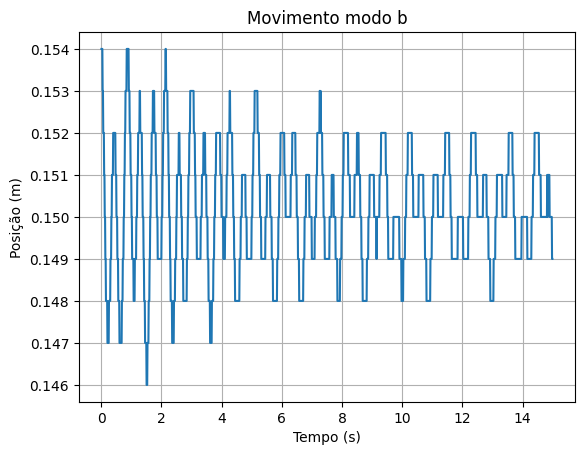

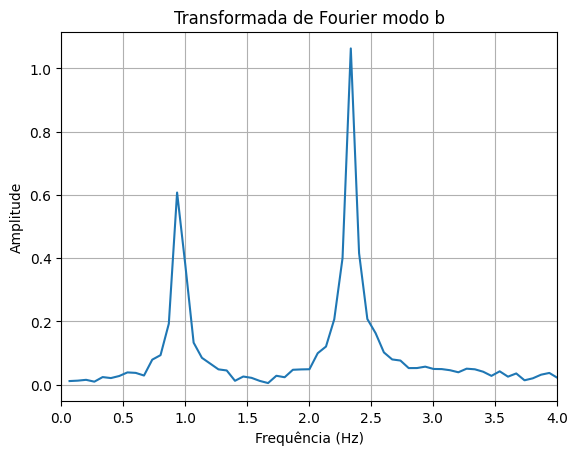

Maior Frequência: 2.3348899266177447 Hz
Menor Frequência: 0.9339559706470979 Hz
frequencia angular maior: 14.670546080806236
frequencia angular menor: 5.868218432322495


In [ ]:
#Deu algum problema no nosso aí eu mexi separado da função

t, x = carregando_dados('pendulocmola1_modob.txt')
t, x = CortaListas(t, x, 15)


plt.plot(t, x)
plt.title("Movimento modo b" )
plt.xlabel("Tempo (s)")
plt.ylabel("Posição (m)")
plt.grid()
plt.show()

f, A = Fast_Fourier(t, x)
A = np.abs(A)

plt.plot(f, A)
plt.title("Transformada de Fourier modo b")
plt.xlabel("Frequência (Hz)")
plt.ylabel("Amplitude")
plt.grid()
plt.xlim(0, 4)
#plt.ylim(2, 2.4)
#plt.xlim(0, x_max)
plt.show()

# Frequência do segundo maior pico:
indices_ordenados = np.argsort(A)[::-1]
f1 = f[indices_ordenados[0]]
f2 = f[indices_ordenados[1]]

print("Maior Frequência:", f1, "Hz")
print("Menor Frequência:", f2, "Hz")
print("frequencia angular maior:", 2 * np.pi * f1)
print("frequencia angular menor:", 2 * np.pi * f2)



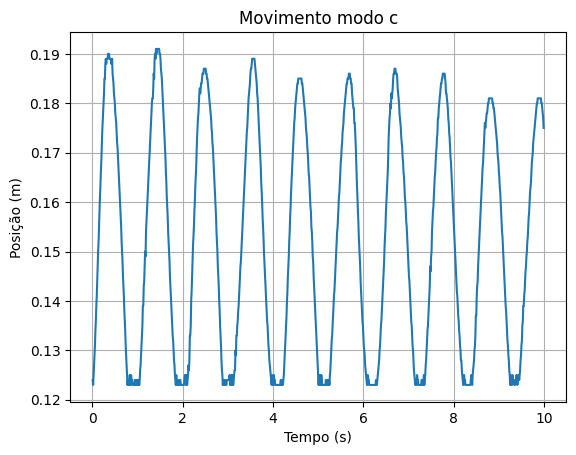

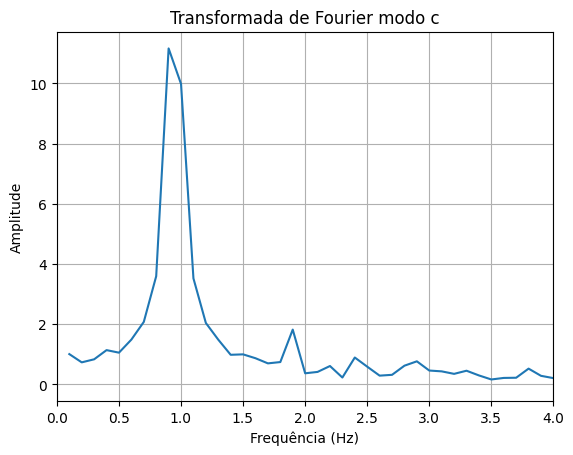

Frequência dominante: 0.9009009009009007 Hz
frequencia angular: 5.660527303765392


In [ ]:
f = plot_graficos("pendulocmola1_modoc.txt", "modo c")
print("Frequência dominante:", f, "Hz")
print("frequencia angular:", 2 * np.pi * f)

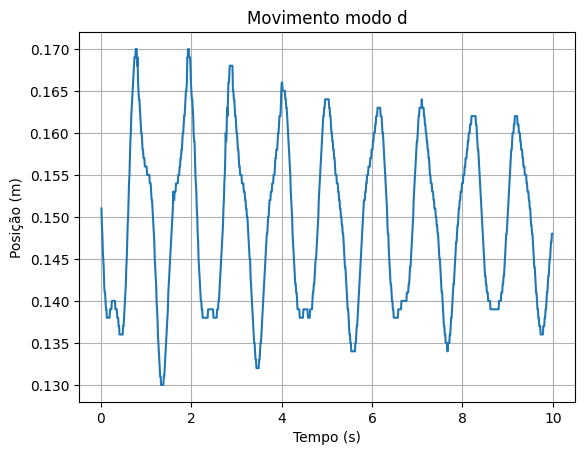

In [ ]:
#plotar p x t do modo d
t_, x_ = carregando_dados('pendulocmola1_modod_1.txt')
t, x = CortaListas(t_, x_, 10)

plt.plot(t, x)
plt.title("Movimento modo d" )
plt.xlabel("Tempo (s)")
plt.ylabel("Posição (m)")
plt.grid()
plt.show()



In [ ]:
#Calcular as frequências usando k m l:


# Experimento 2: Oscilações não lineares

In [ ]:
def Lei_de_Hooke(massas, deformacoes):
  forcas = []
  for i in range(len(massas)):
    forcas.append(massas[i] * g)

  result  = cp.stats.linregress(deformacoes, forcas)
  slope, intercept, r, p, stderr = result
  intercept_stderr = result.intercept_stderr

  texto = (
    f'Ajuste Linear: Ax+b = y\n'
    f'A = {slope:.2f}+/- {stderr:.2f}\n'
    f'b = {intercept:.2f} +/- {intercept_stderr:.2f}'
  )


  plt.plot(deformacoes, forcas, 'o', label='Medidas experimentais')
  plt.plot(deformacoes, [intercept + slope * x for x in deformacoes], 'r', label='ajuste linear')
  plt.text(0.05, 0.95, texto, fontsize=10, bbox=dict(boxstyle='round', fc='lightblue', ec='black', alpha=0.5),transform=plt.gca().transAxes, va='top')
  plt.title("Força x Deformação")
  plt.xlabel("Deformação (m)")
  plt.ylabel("Força (N)")
  plt.grid()
  plt.legend()
  plt.show()

  return (-1 * slope)


In [ ]:
def Osciladores_nao_lineares(file):
  dados = pd.read_csv(file, skiprows=2,delimiter="\t",encoding="latin1")
  dados[dados.columns[0]] = dados[dados.columns[0]].str.replace(",", ".").astype(float)
  dados[dados.columns[1]] = dados[dados.columns[1]].str.replace(",", ".").astype(float)

  tempo = dados[dados.columns[0]].tolist()
  posicao = dados[dados.columns[1]].tolist()

  plt.plot(tempo, posicao)
  plt.title("Movimento")
  plt.xlabel("Tempo (s)")
  plt.ylabel("Posição (m)")
  plt.grid()
  plt.show()

  indices_picos, _ = find_peaks(posicao, distance=30, prominence=0.01)
  posicoes_picos = [posicao[i] for i in indices_picos]

  T = []
  A = []
  frequencia_angular = []

  for i in range(1,len(indices_picos)):
    t1 = tempo[indices_picos[i-1]]
    t2 = tempo[indices_picos[i]]
    T.append(t2 - t1)
    A.append(posicao[indices_picos[i]])
    frequencia_angular.append(2 * np.pi / T[i - 1])


  result = cp.stats.linregress(frequencia_angular, A)
  slope, intercept, r, p, stderr = result
  intercept_stderr = result.intercept_stderr

  texto = (
    f'Ajuste Linear: Ax+b = y\n'
    f'A = {slope:.3f} +/- {stderr:.3f}\n'
    f'b = {intercept:.3f} +/- {intercept_stderr:.3f}'
  )

  plt.plot(frequencia_angular, A, 'o', label='Medidas experimentais')
  plt.plot(frequencia_angular, [intercept + slope * x for x in frequencia_angular], 'r', label='ajuste linear')
  plt.title("Amplitude x Frequencia Angular")
  plt.text(0.05, 0.95, texto, fontsize=10, bbox=dict(boxstyle='round', fc='lightblue', ec='black', alpha=0.5),transform=plt.gca().transAxes, va='top')
  plt.xlabel("Frequencia Angular (rad/s)")
  plt.ylabel("Apmlitude(m)")
  plt.grid()
  plt.legend()
  plt.show()


  print("Valores dos Periodos:",T)
  print("Frequencia angular:", frequencia_angular)
  print("Valores Amplitude:", A)




[0.08, 0.13, 0.22, 0.17]


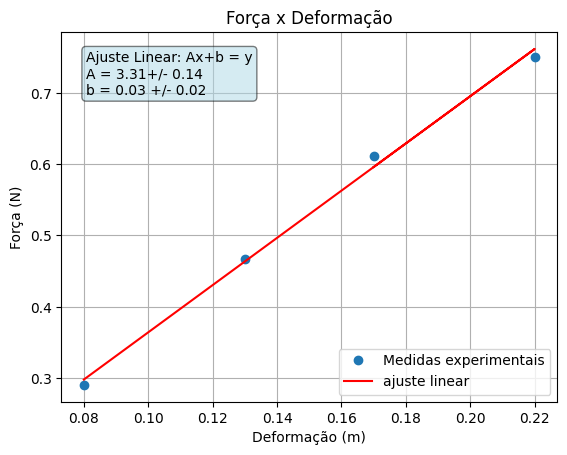

[0.2905793352, 0.4666880232000001, 0.7504186872, 0.6114885]


In [ ]:
m =[29.7 * 10**(-3), 47.7 * 10**(-3), 76.7 * 10**(-3), 62.5 * 10**(-3)] #massa (kg)
l = [(140 - 132) * 10**(-2), (145 - 132)* 10**(-2), (154 - 132)* 10**(-2), (149 - 132)* 10**(-2)] #Deformação (m)
print(l)
Lei_de_Hooke(m,l)
forcas = []
for i in range(len(m)):
  forcas.append(m[i] * g)
print(forcas)

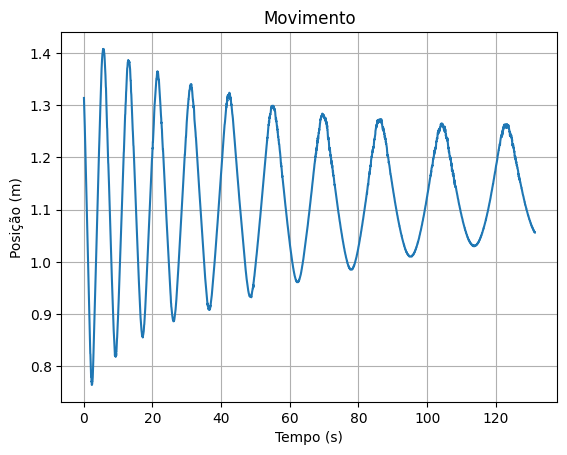

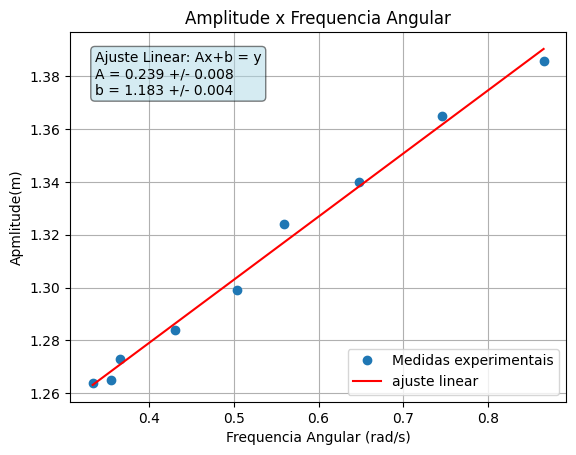

Valores dos Periodos: [7.257899999999999, 8.420900000000001, 9.7041, 11.227899999999998, 12.4709, 14.5963, 17.2029, 17.683999999999997, 18.84700000000001]
Frequencia angular: [0.8657029315889702, 0.7461417790473209, 0.64747738658707, 0.5596046729290061, 0.5038277355427103, 0.43046424828070035, 0.3652398902033719, 0.3553033989583571, 0.33337853807924783]
Valores Amplitude: [1.386, 1.365, 1.34, 1.324, 1.299, 1.284, 1.273, 1.265, 1.264]


In [ ]:
Osciladores_nao_lineares("serie 6.txt")

Simulação oscilador x³ amortecido (problema opcional)

In [ ]:
def oscilador(y, t, h, m, b):
  # Equação do movimento
  x, v = y
  dvdt = (-h * x**3 - b * v) / m
  return [v, dvdt]


In [ ]:
# Parâmetros físicos
#h = 1.6
h =20
m = 0.21
b_values = [0.01, 0.0432 , 0.5]
labels = ['b=0,01', 'b=0,0432', 'b=0,5']

# Condições iniciais
x0 = 0.3
v0 = 0.0
y0 = [x0, v0]

# Tempo de simulação
t = np.linspace(0, 200, 10000)

In [ ]:
sol = cp.integrate.odeint(oscilador, y0, t, args=(h, m,b_values[0]))
sol1 = cp.integrate.odeint(oscilador, y0, t, args=(h, m,b_values[1]))
sol2 = cp.integrate.odeint(oscilador, y0, t, args=(h, m,b_values[2]))


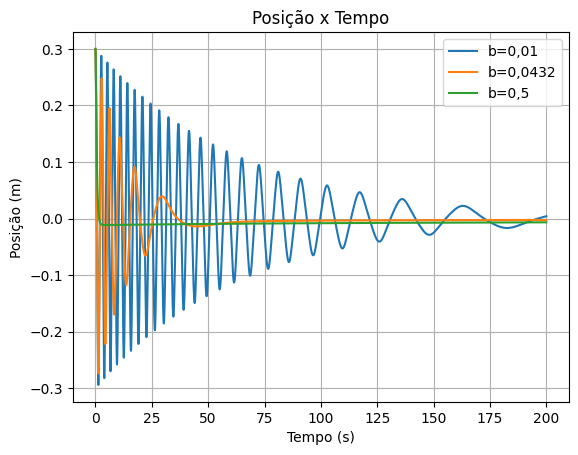

In [ ]:
plt.plot(t, sol[:, 0], label=labels[0])
plt.plot(t, sol1[:, 0], label=labels[1])
plt.plot(t, sol2[:, 0], label=labels[2])
plt.title('Posição x Tempo')
plt.xlabel('Tempo (s)')
plt.ylabel('Posição (m)')
plt.legend()
plt.grid()
plt.show()

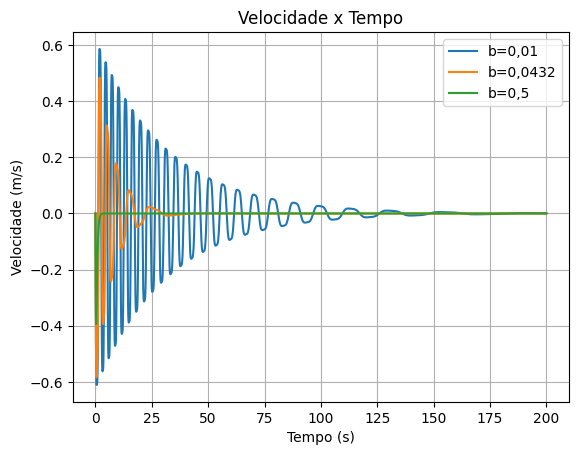

In [ ]:
plt.plot(t, sol[:,1], label=labels[0])
plt.plot(t, sol1[:,1], label=labels[1])
plt.plot(t, sol2[:,1], label=labels[2])
plt.title('Velocidade x Tempo')
plt.xlabel('Tempo (s)')
plt.ylabel('Velocidade (m/s)')
plt.legend()
plt.grid()
plt.show()

#Experimento 3: Análise de Fourier do som

In [ ]:
def analise_som(file_name):
  #importar
  arquivo = wave.open(file_name, 'r')
  n_channels = arquivo.getnchannels()
  sample_width = arquivo.getsampwidth()
  frame_rate = arquivo.getframerate()
  n_frames = arquivo.getnframes()
  frames = arquivo.readframes(n_frames)
  arquivo.close()

  #Análise
  if sample_width == 1:
    fmt = "{}B".format(n_frames * n_channels)
  elif sample_width == 2:
    fmt = "{}h".format(n_frames * n_channels)

  audio_data = struct.unpack(fmt, frames)
  audio_data = np.array(audio_data)
  tempo = np.linspace(0, n_frames / frame_rate, num=len(audio_data))

  plt.plot(tempo, audio_data, color='blue')
  plt.title("Forma de Onda do Áudio")
  plt.xlabel("Tempo (s)")
  plt.ylabel("Amplitude")
  plt.xlim(0.01, 0.05)
  plt.grid(True)
  plt.tight_layout()
  plt.show()

  #fft
  Magnitude = np.abs(np.fft.rfft(audio_data))
  Frequencia = np.fft.rfftfreq(len(audio_data), 1/frame_rate)

  indice_max = np.argmax(Magnitude)
  frequencia_fundamental = Frequencia[indice_max]

  plt.plot(Frequencia, Magnitude)
  plt.title("Transformada de Fourier")
  plt.xlabel("Frequência (Hz)")
  plt.ylabel("Magnitude")
  plt.grid(True)
  plt.tight_layout()
  plt.show()

  print("Frequência Fundamental:", frequencia_fundamental, "Hz")


In [ ]:
def calculo_frequencias(L,cumprimento_boca, largura_boca, aberto):
  #Colocar 1 sw
  v_s = 330
  # Quantos harmônicos queremos calcular:
  n_max = 3

  #a = (cumprimento_boca + largura_boca)/ 4
  a = np.sqrt((cumprimento_boca *largura_boca)/np.pi)

  if aberto:
    delta_e = 0.6 * a
  else:
    delta_e = 0

  delta_b = 2.3 * a**2 / np.sqrt(cumprimento_boca * largura_boca)

  #Você pode conferir se é para usar os dois deltas em todos os casos
  Lef = L + delta_e + delta_b

  if (aberto == 1):
    return [n * v_s / (2 * Lef) for n in range(1, n_max + 1)]
  else:
    return [n * v_s / (4 * Lef) for n in range(1, 2 * n_max, 2)]




In [ ]:
def plotar_ondas_estacionarias(L=1.0, aberto=True):
    n_max = 3
    x = np.linspace(0, L, 1000)
    plt.figure(figsize=(10, 6))

    for i in range(1, n_max + 1):
        if aberto:
            n = 2 * i - 1
            y = np.sin(n * np.pi * x / (2 * L))
            tipo = "Tubo Aberto em uma extremidade"
            label = rf"$n={n}$"
        else:
            n = i
            y = np.sin(n * np.pi * x / L)
            tipo = "Tubo Fechado"
            label = rf"$n={n}$"

        plt.plot(x / L, y, label=label, linewidth=2)

    # Linha de equilíbrio (nó zero)
    plt.axhline(0, color='gray', linestyle='--', linewidth=1)

    # Eixos físicos
    plt.xlabel(r'Posição normalizada $x/L$', fontsize=14)
    plt.ylabel(r'Deslocamento transversal $y(x)$', fontsize=14)
    plt.title(f'Ondas Estacionárias em {tipo}', fontsize=16)
    plt.legend(title="Harmônicos", fontsize=12)
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.xticks(np.linspace(0, 1, 6))
    plt.yticks(np.linspace(-1, 1, 5))

    plt.tight_layout()
    plt.show()

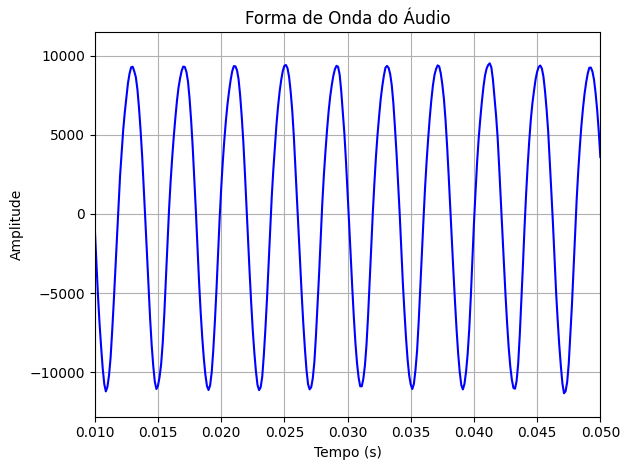

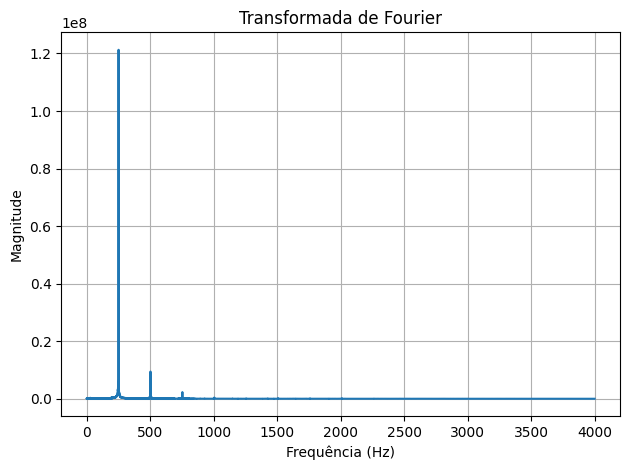

Frequência Fundamental: 251.25 Hz
3 primeiros harmônicos: [np.float64(213.53341998958663), np.float64(427.06683997917327), np.float64(640.6002599687598), np.float64(854.1336799583465)]


In [ ]:
analise_som("chris_tuboaberto.wav")
Frequencias_3 = calculo_frequencias(0.58, 0.09, 0.36, True)
print("3 primeiros harmônicos:",Frequencias_3)


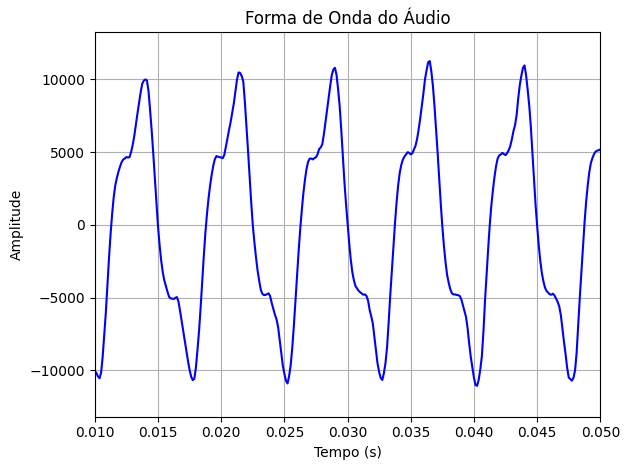

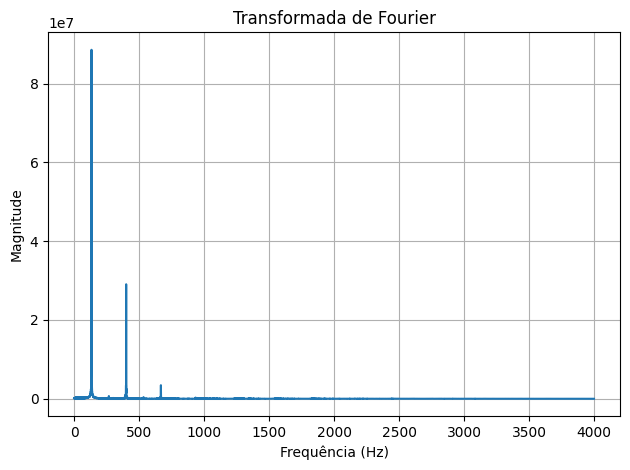

Frequência Fundamental: 133.57142857142856 Hz
3 primeiros harmônicos: [np.float64(115.90655266132585), np.float64(347.7196579839775), np.float64(579.5327633066292), np.float64(811.345868629281)]


In [ ]:
analise_som("chris_tubofechado.wav")
Frequencias_3 = calculo_frequencias(0.58, 0.09, 0.36, False)
print("3 primeiros harmônicos:",Frequencias_3)

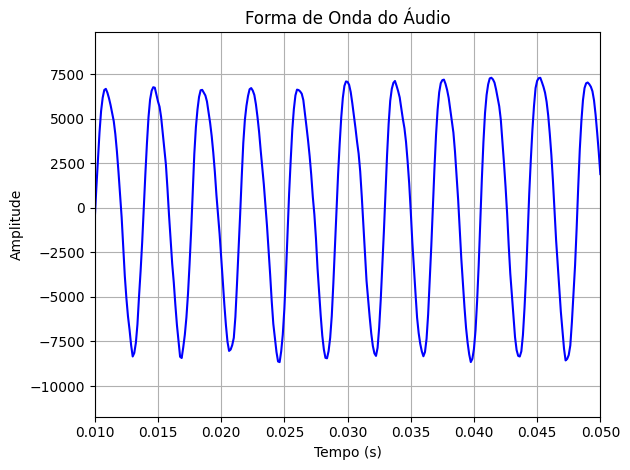

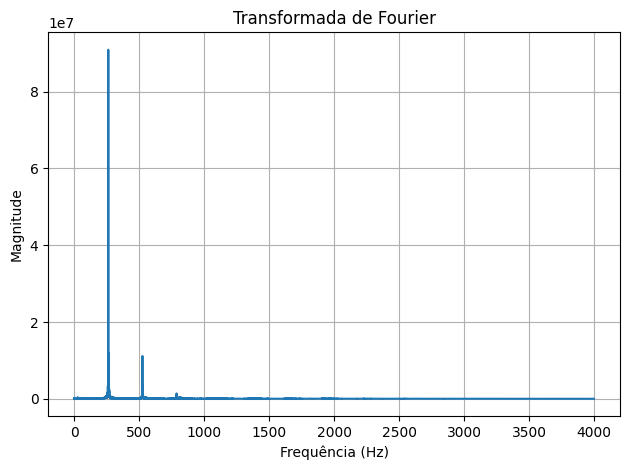

Frequência Fundamental: 262.66666666666663 Hz
3 primeiros harmônicos: [np.float64(206.53654294984443), np.float64(413.07308589968886), np.float64(619.6096288495332), np.float64(826.1461717993777)]


In [ ]:
analise_som("chris_retanguloaberto.wav")
Frequencias_3 = calculo_frequencias(0.58, 0.11, 0.38, True)
print("3 primeiros harmônicos:",Frequencias_3)

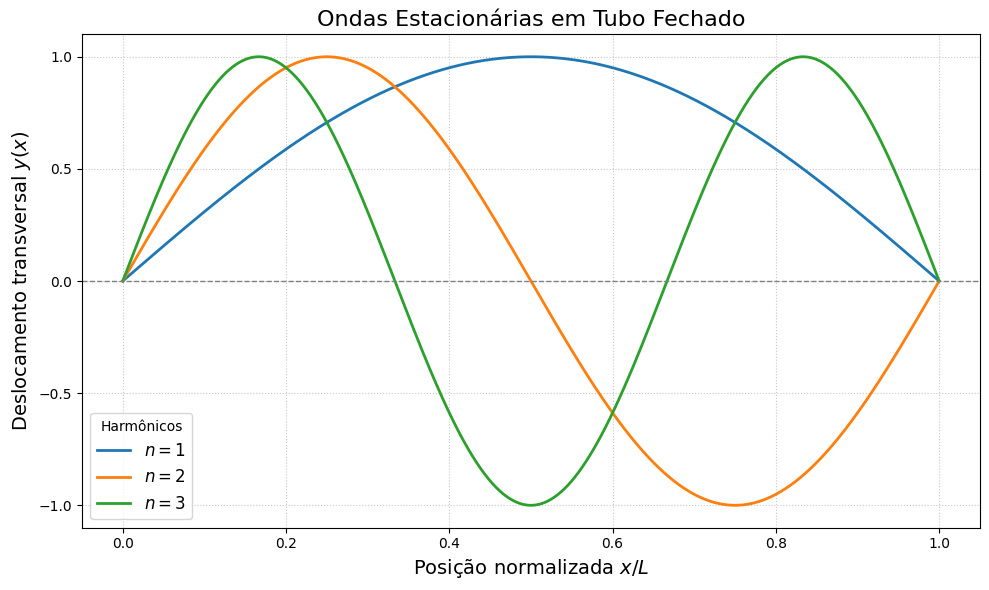

In [ ]:
plotar_ondas_estacionarias(0.65, False )

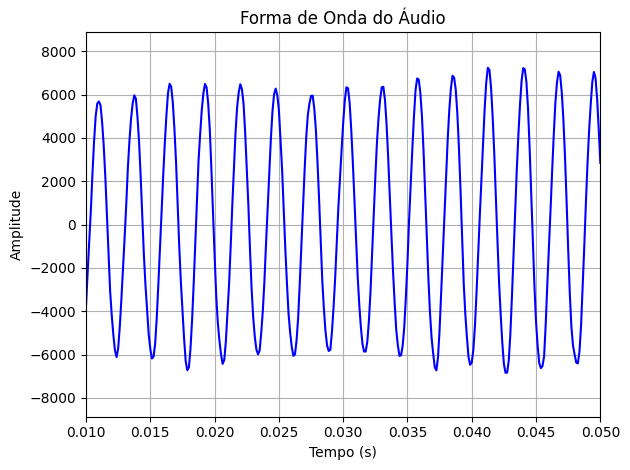

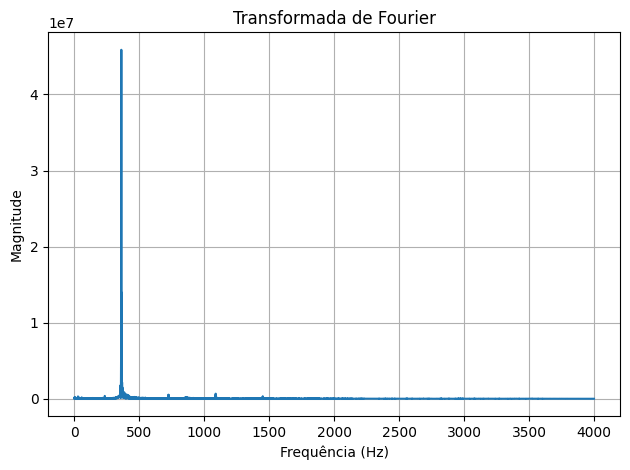

Frequência Fundamental: 363.07692307692304 Hz
[np.float64(363.4245316480532), np.float64(726.8490632961064), np.float64(1090.2735949441594)]


In [ ]:
analise_som("quadrado aberto 4.wav")
#L2 = 37.8 , 7.1, 7.1 #quadrado aberto
Frequencias_2 = calculo_frequencias(0.378, 0.071, 0.071, True)
print(Frequencias_2)

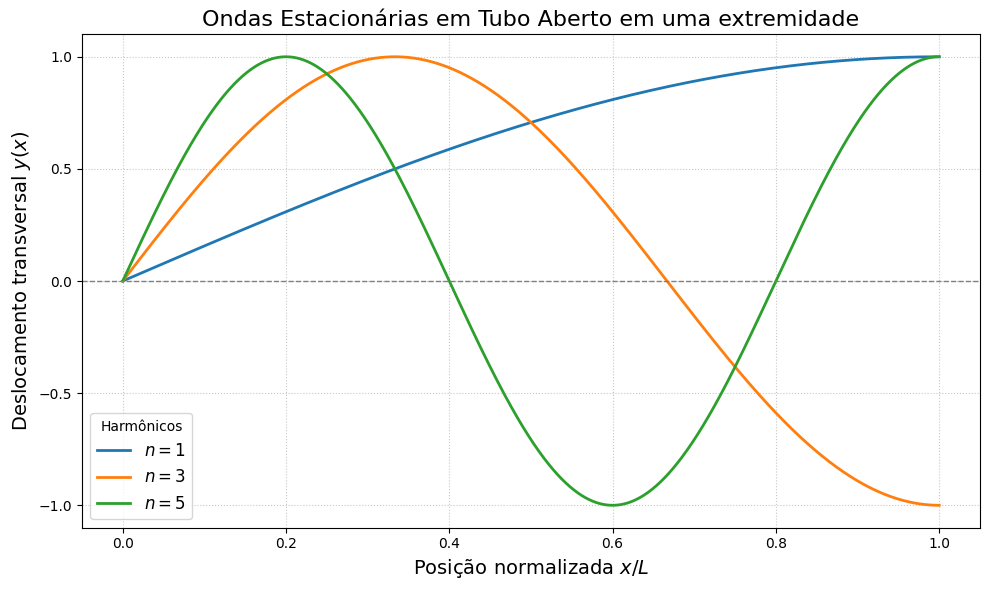

In [ ]:
plotar_ondas_estacionarias(0.378, True)

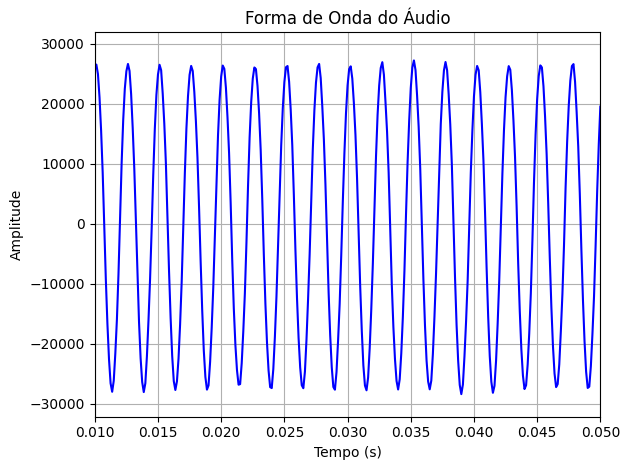

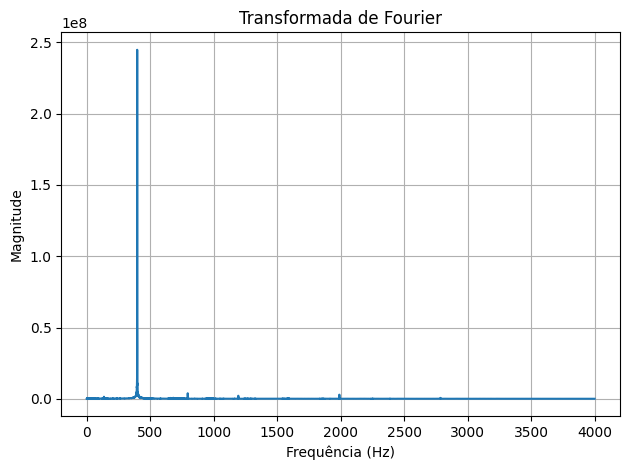

Frequência Fundamental: 397.9166666666667 Hz
[np.float64(120.47278336900828), np.float64(361.4183501070249), np.float64(602.3639168450414)]


In [ ]:
analise_som("quadrado fechado 4.wav")
#L1 = 64.6, 5.3 , 5.3 #quandrado fechado
Frequencias_1 = calculo_frequencias(0.646, 0.053, 0.053, False)
print(Frequencias_1)


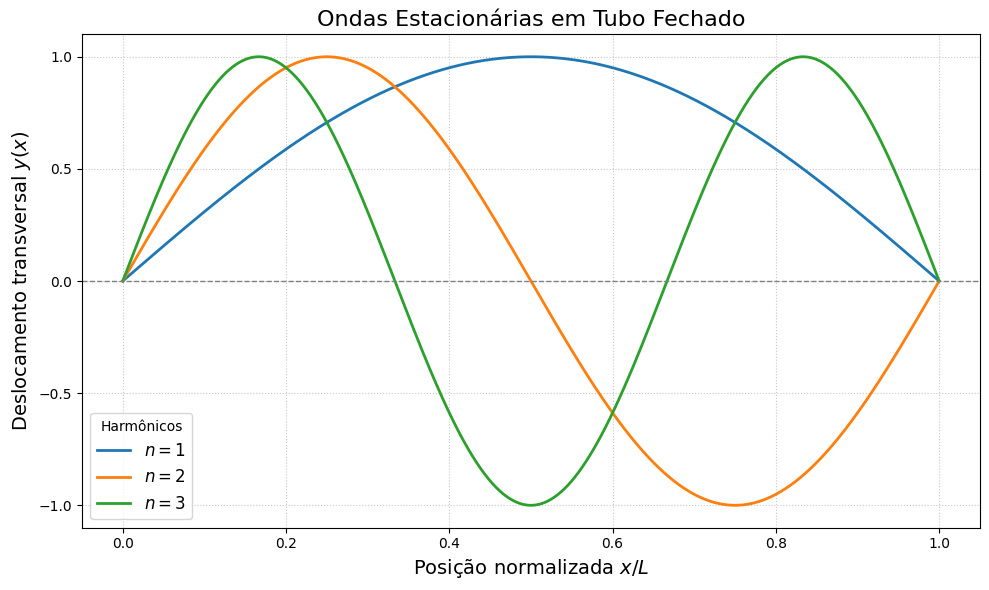

In [ ]:
plotar_ondas_estacionarias(0.646, False)

#Experimento 4: Microondas

PARTE A

In [ ]:
distancia = [83,79,76,73,70,67,66,64,63,58,59] # cm
V = [0.1, 0.18, 0.32, 0.5, 0.66, 0.76, 0.8, 0.9, 1.08, 0.36, 0.35] # mA
d_10 = [(73.8 - 58), (71.8 - 52), (66.3 -50)]              #Distância entre 10 nós em cm


d= []                  #Distancia entre nós em m
for i in d_10:
  d.append(i/1000)
#SI(cm -> m     mA -> A)
for i in range(len(distancia)):
  distancia[i] = distancia[i]/100

for i in range(len(V)):
  V[i] = V[i]/1000

In [ ]:
def Grafico_distancia_tensao(D, V):
  plt.scatter(D, V, marker='o', label='Dados experimentais')
  plt.title("TITULO", fontsize=14)
  plt.xlabel("distancia", fontsize=12)
  plt.ylabel("tensao", fontsize=12)
  plt.grid()
  plt.show()



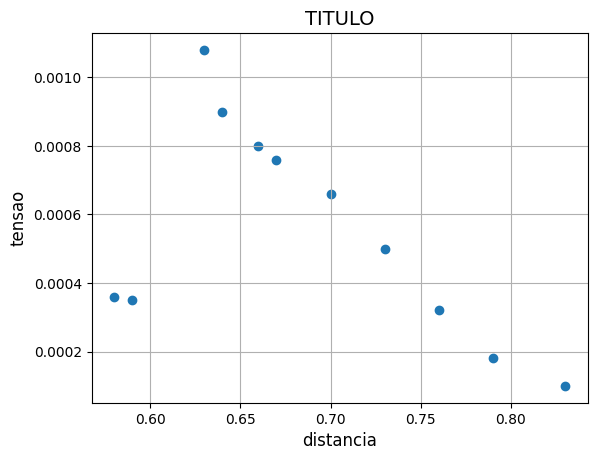

In [ ]:
Grafico_distancia_tensao(distancia, V)
#Eu sinceramente não acho que tem utilidade ao relatório, mas eu queria visualizar graficamente

In [ ]:
def Comprimento_onda_medio(lista_d):
  lista_comprimento = []
  for i in lista_d:
    lista_comprimento.append(2 * i )
  comprimento_medio = sum(lista_comprimento)/len(lista_comprimento )
  return (comprimento_medio)

In [ ]:
print("comprimento_onda: (", Comprimento_onda_medio(d), " +/- ", Desvio_padra(d), ")m")

comprimento_onda: ( 0.03459999999999999  +/-  0.0021794494717703367 )m


In [ ]:
def Frequencia(comprimento_de_onda):
  v = 3.00 * 10**8 #m/s
  return(v/comprimento_de_onda)

#Aqui não há forma de calcular incerteza?

In [ ]:
print("frequencia:", Frequencia(Comprimento_onda_medio(d)), "Hz")

frequencia: 8670520231.213875 Hz


PARTE B

In [ ]:
theta = 17 #Graus
theta_1 = 21.53 #Calculada pela tangente do triangulo
theta_2 = theta + theta_1

Volume = 0.500
massa = 0.3346
n_estireno = 1.5164

In [ ]:
def Indice_de_refracao (t1, t2):
  #Usando a lei de Snell
  n = np.sin(grau_radiano(t2))/np.sin(grau_radiano(t1))
  return n


In [ ]:
print("indice de refracao do prisma preenchido de bolinhas de estireno:", Indice_de_refracao(theta_1, theta_2))

indice de refracao do prisma preenchido de bolinhas de estireno: 1.6973954012488595


In [ ]:
print("n_bolinhas/n_estireno =", Indice_de_refracao(theta_1, theta_2)/(n_estireno))

n_bolinhas/n_estireno = 1.119358613326866


# Experimento 5:

In [ ]:
def carregando_dados(file):
  dados = pd.read_csv(file, skiprows=2,delimiter="\t",encoding="latin1")

  dados[dados.columns[0]] = dados[dados.columns[0]].str.replace(",", ".").astype(float)
  dados[dados.columns[1]] = dados[dados.columns[1]].str.replace(",", ".").astype(float)

  tempo = dados[dados.columns[0]].tolist()
  intensidade = dados[dados.columns[1]].tolist()

  return tempo, intensidade

In [ ]:
def intensidade_teorica_fenda_dupla(x, a, d, lambd, D):

  beta = (np.pi * a / lambd) * (x / D)
  termo_difracao = np.sinc(beta / np.pi)**2


  alpha = (np.pi * d / lambd) * (x / D)
  termo_interferencia = np.cos(alpha)**2

  I = termo_interferencia * termo_difracao
  return I

def intensidade_teorica_fenda_unica(x, a, lambd, D):

  beta = (np.pi * a / lambd) * (x / D)
  termo_difracao = np.sinc(beta / np.pi)**2

  I =  termo_difracao
  return I


In [ ]:
def Faz_grafico_5(t1, I1, t2, I2, t3, I3):
  # Como mudar de tempo -> posição
  P1 = []
  P2 = []
  P3 = []

  #Argumento maximo
  indice_max1 = np.argmax(I1)
  indice_max2 = np.argmax(I2)
  indice_max3 = np.argmax(I3)

  #Tempo -> posição (por algum motimos anotamos s/cm invés de cm/s)
  for i in range(len(t1)):
    P1.append(t1[i]/ 0.5)
  for i in range(len(t2)):
    P2.append(t2[i] / 1)
  for i in range(len(t3)):
    P3.append(t3[i]/ 0.5)

  P1_pico = P1[indice_max1]
  P2_pico = P2[indice_max2]
  P3_pico = P3[indice_max3]

  #centralizando e passando para metro
  for i in range(len(P1)):
    P1[i] = (P1[i] - P1_pico) /100
  for i in range(len(P2)):
    P2[i] = (P2[i] - P2_pico)/100
  for i in range(len(P3)):
    P3[i] = (P3[i] - P3_pico)/100





  plt.plot(P1, I1, label='fenda dupla d = 250mm', color = 'lightblue')
  plt.plot(P2, I2, label='fenda dupla d= 500mm', color = 'green')
  plt.plot(P3, I3, label='fenda unica', color = '#FF0000')
  plt.title("Intensidade x Posição")
  plt.xlabel("Posição (m)")
  plt.ylabel("Intensidade luz (% max da escala)")
  plt.legend()
  plt.grid()
  plt.show()

  I1_teorico = intensidade_teorica_fenda_dupla(np.array(P1), 0.04 * 10**(-3), 0.25, 632 * 10**(-9), 1.92 )
  I1 = np.array(I1)/ np.max(I1)
  plt.plot(P1, I1, label='Experimental')
  plt.plot(P1, I1_teorico, label='Teórica')
  plt.title("Fenda dupla d = 250mm")
  plt.xlabel("Posição (m)")
  plt.ylabel("Intensidade luz (% max da escala)")
  plt.legend()
  plt.grid()
  plt.show()

  I2_teorico = intensidade_teorica_fenda_dupla(np.array(P2), 0.04 * 10**(-3), 0.5, 632 * 10**(-9), 1.92)
  minimo2 = np.min(I2)
  for i in range(len(I2)):
    I2[i] = I2[i] - minimo2
  I2 = np.array(I2)/ np.max(I2)
  plt.plot(P2, I2, label='Experimental')
  plt.plot(P2, I2_teorico, label='Teórica')
  plt.title("Fenda dupla d = 500mm")
  plt.xlabel("Posição (m)")
  plt.ylabel("Intensidade luz (% max da escala)")
  plt.legend()
  plt.grid()
  plt.show()

  I3_teorico = intensidade_teorica_fenda_unica(np.array(P3), 0.04 * 10**(-3), 632 * 10**(-9), 1.92)
  I3 = np.array(I3)/ np.max(I3)
  plt.plot(P3, I3, label='Experimental')
  plt.plot(P3, I3_teorico, label='Teórica')
  plt.title("Fenda única")
  plt.xlabel("Posição (m)")
  plt.ylabel("Intensidade luz (% max da escala)")
  plt.legend()
  plt.grid()
  plt.show()




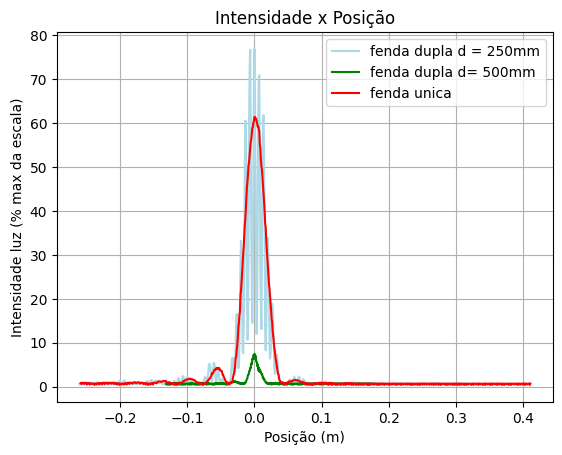

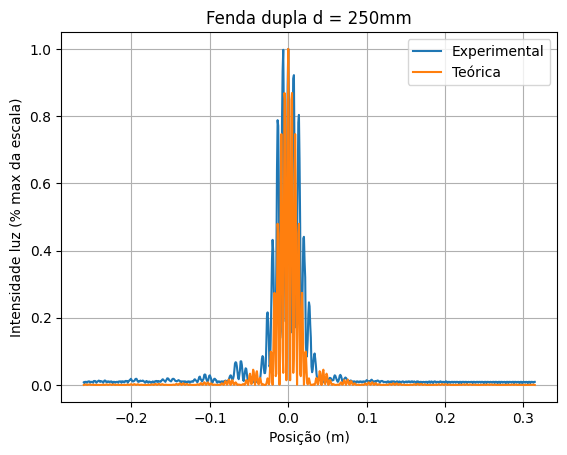

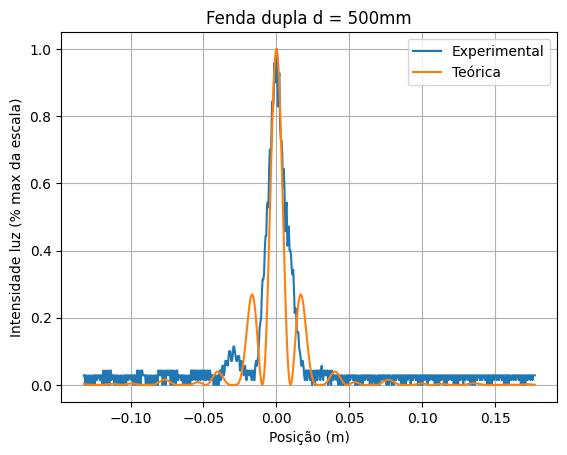

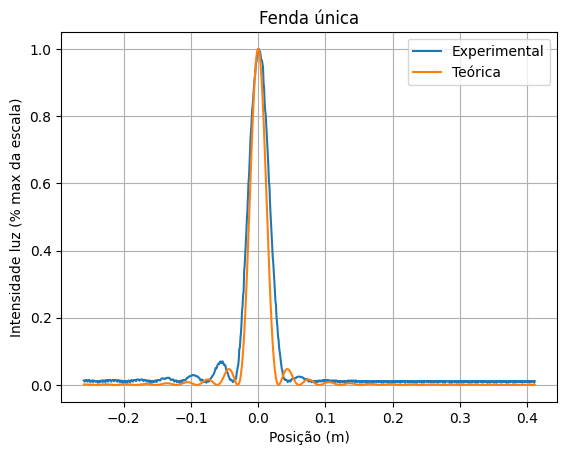

In [ ]:
Tempo1, Intensidade1 = carregando_dados("fenda dupla 04mm - d = 250 mm - 1.txt")
Tempo2, Intensidade2 = carregando_dados("fenda dupla 04mm - d = 500 mm - 1 s_cm - 1.txt")
Tempo3, Intensidade3 = carregando_dados("fenda unica 04mm - 1.txt")
Faz_grafico_5(Tempo1, Intensidade1, Tempo2, Intensidade2, Tempo3, Intensidade3)

# Experimento 6: Dispersão da luz em um prisma

Etapa 1:

In [ ]:
#Eu não entendo os valores anotados muito bem kkkk
phis1 = [236.64, 231.2, 232.6, 216.1, 241.7]
phis2 = [128.8, 123.4, 124.75, 108.2, 133.8]
lista_R = []
lista_A = []

for i in range(len(phis1)):
  lista_R.append(phis1[i] - phis2[i])
  lista_A.append(lista_R[i]/2)

A, dA = Erro_padrao(lista_A)

In [ ]:
print("A:", A, "+\-", dA)

A: 54.00899999999999 +\- 0.08562125904236668


Etapa 2+3:

In [ ]:
#deltas_azul = []
#deltas_vermelho = []
#deltas_laranja = []
#deltas_amarelo = []
#deltas_verde = []
#deltas_violeta = []

#lista_cores =["vermelho", "amarelo", "verde", "ciano", "azul", "violeta" ]
#deltas_minimo = []
#cumprimentos_de_onda = [6907.2 * 10**(-10) , 5790.7* 10**(-10), 5469.7* 10**(-10), 4916.0* 10**(-10), 4358.3* 10**(-10), 4077.8* 10**(-10)]
#for i in range(len(lista_cores)):

#  nome = "deltas_" + lista_cores[i]
#  delta, ddelta = Erro_padrao(nome)
#  deltas_minimo.append(delta)


In [ ]:
#lista_cores =["vermelho", "laranja", "verde", "ciano", "violeta" ]
#deltas_minimo = [132.3333, 130.6667, 130.8333, 130.25, 128.8333]
#cumprimentos_de_onda = [6907.2e-10, 5790.7e-10, 5469.7e-10, 4916.0e-10, 4358.3e-10]

lista_cores =["vermelho", "laranja", "verde", "ciano", "violeta" ]
deltas_minimo = [132.3333, 131.5, 130.8333, 130.25, 128.8333]
comprimentos_de_onda = [6907.2e-10, 5790.7e-10, 5469.7e-10, 4916.0e-10, 4358.3e-10]
lista_n = []

 #laranja claro  []

In [ ]:
def calcula_n(A, delta):
  n = np.sin(np.radians((delta + A)/2))/ np.sin(np.radians(A/2))
  #n = np.sin((np.radians(delta) + A)/2)/ np.sin(np.radians(A/2))
  return n

In [ ]:
for i in range(len(lista_cores)):
  nome = lista_cores[i]
  n = calcula_n(A, deltas_minimo[i])
  lista_n.append(n)
  print("n para", nome, ":", n)

n para vermelho : 2.2020791069660692
n para laranja : 2.202896858465359
n para verde : 2.203467236494541
n para ciano : 2.2039050896611996
n para violeta : 2.204730739768279


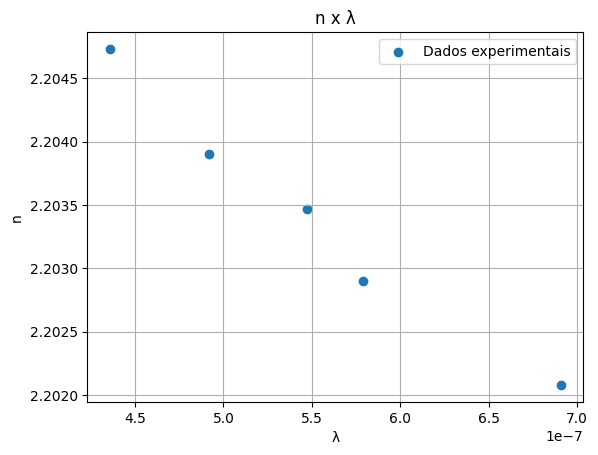

In [ ]:
plt.scatter(comprimentos_de_onda, lista_n, label='Dados experimentais')
plt.title("n x λ")
plt.xlabel("λ")
plt.ylabel("n")
plt.legend()
plt.grid()
plt.show()

Determinação semi-quantitativa de parâmetros microscópicos

In [ ]:
from scipy.optimize import curve_fit
def calcular_omega(lambda_m, n_medio):
    c = 2.998e8
    return 2 * np.pi * c / (lambda_m * n_medio)

def linear_model(omega_sq, a, b):
    return a - b * omega_sq


In [ ]:
# Cálculos para o gráfico linearizado
omega_sq = (2 * np.pi * 2.998e8 / (np.array(comprimentos_de_onda) * np.array(lista_n)))**2
inv_n_sq_minus_1 = 1 / (np.array(lista_n)**2 - 1)

In [ ]:
# Ajuste linear
popt, pcov = curve_fit(linear_model, omega_sq, inv_n_sq_minus_1)
a, b = popt
omega_0 = np.sqrt(a / b)
f = 1 / np.sqrt(b * omega_0**2)
print(f"ω₀ = {omega_0:.2e} rad/s")
print(f"f = {f:.4f}")
lambda_res = 2 * np.pi * 2.998e8 / omega_0
print(f"λ_res = {lambda_res*1e9:.1f} nm")

ω₀ = 2.78e+16 rad/s
f = 1.9601
λ_res = 67.8 nm


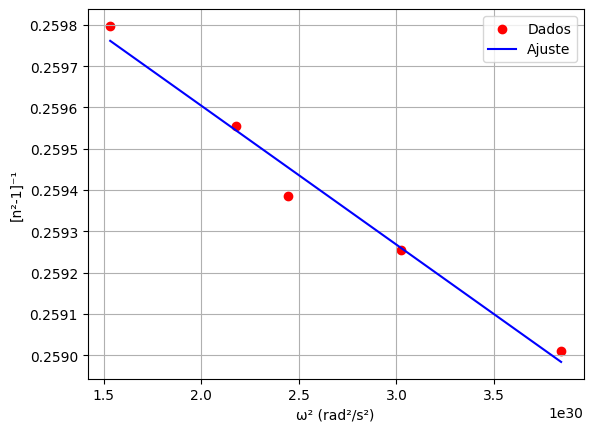

In [ ]:
plt.scatter(omega_sq, inv_n_sq_minus_1, c='r', label='Dados')
plt.plot(omega_sq, linear_model(omega_sq, a, b), 'b-', label='Ajuste')
plt.xlabel('ω² (rad²/s²)')
plt.ylabel('[n²-1]⁻¹')
plt.legend()
plt.grid()
plt.show()

# Experimento 7: Lei de Fresnel para reflexão

Fazendo os gráficos experimentais

In [ ]:
# As medidas tiradas do equipamento são de intensidade, precisamos dividir as medidas pela intensidade total do laser e depois tirar a raiz
#só depois disso q teremos as medidas do indice de fresnel(chi)

def lista_coeficiente(I0, I):
  chi = []
  for i in range(len(I)):
    chi.append(np.sqrt(I[i]/I0))
  return chi



In [ ]:
# fazer o grafico dos indices para descobrir o indice de refração

def plot1(alpha1, chi1, alpha2, chi2):
  plt.plot(alpha1, chi1, 'o-', label='coeficiente perpendicular')
  plt.plot(alpha2, chi2, 'x-', label = 'coeficiente perpendicular')

  plt.grid()

  plt.show()

In [ ]:
#fazer grafico com todos a parte exp + teorica

def plotfinal(alpha1, chi1, alpha2, chi2, n):
  x = np.linspace(0, 80, 100)
  y1= []
  y2=[]

  for i in range(len(x)):
    #y1.append(np.abs(((np.sqrt((n**2) - (np.sin(x[i] * np.pi / 180))**2) - np.cos(x[i] * np.pi / 180))**2) / ((n**2) - 1)))
    y1.append(np.abs(((np.sqrt((n**2) - (np.sin(x[i] * np.pi / 180))**2) - np.cos(x[i] * np.pi / 180))**2) / ((n**2) - 1)))

  #curva
  #termo1 = (n**2) * np.cos(x * np.pi / 180)
  #termo2 = np.sqrt((n**2) - (np.sin(x * np.pi / 180))**2)
  termo1 = (n**2) * np.cos(np.radians(x))
  termo2 = np.sqrt(n**2 - (np.sin(np.radians(x)))**2)
  for i in range(len(x)):
    #y2.append(((n**2) * np.cos(x[i] * np.pi / 180) - np.sqrt((n**2) - np.sin(x[i] * np.pi / 180)**2)) / ((n**2) * np.cos(x[i] * np.pi / 180) + np.sqrt((n**2) - np.sin(x[i] * np.pi / 180)**2)))
    #y2.append((termo1[i] - termo2[i]) / (termo1[i] + termo2[i]))
    y2.append(np.abs((termo1[i] - termo2[i]) / (termo1[i] + termo2[i])))

  #plt.plot(alpha1, chi1, 'o-', label = 'Exp |ζ⊥|')
  #plt.plot(alpha2, chi2, 'x-', label = 'Exp |ζ‖|')
  plt.scatter(alpha1, chi1, label = 'Exp |ζ⊥|')
  plt.scatter(alpha2, chi2, label = 'Exp |ζ‖|')

  plt.plot(x, y1, label='Teórico |ζ⊥|')
  plt.plot(x, y2, label='Teórico |ζ‖|' )
  plt.legend()
  plt.xlabel('ângulo(graus)')
  plt.ylabel('coeficiente de fresnel')
  plt.grid()
  plt.show()


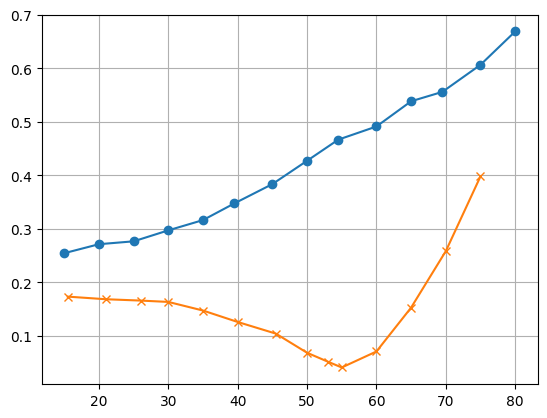

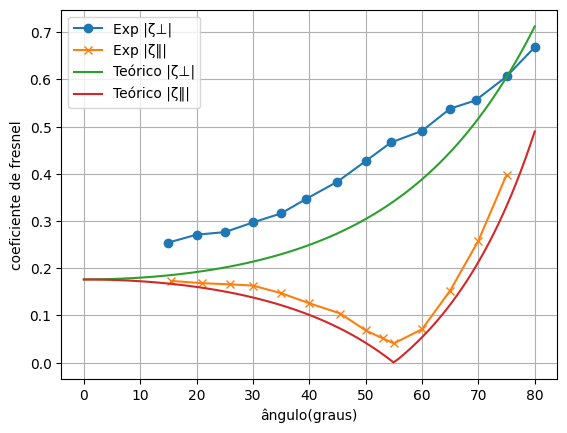

In [ ]:
#Contas LUCAS!
I01 = 340.0
I1 = [22.0, 25.0, 26.0, 30.0, 34.0, 41.0, 50.0, 62.0, 74.0, 82.0, 98.5, 105, 125, 152]
alpha1 = [15, 20, 25, 30, 35, 39.5, 45, 50, 54.5, 60, 65, 69.5, 75, 80]

I02 = 600
I2 = [18, 17, 16.5, 16, 13, 9.5, 6.5, 2.8, 1.6, 1, 3, 14, 40, 95]
alpha2 = [15.5, 21, 26, 30, 35, 40, 45.5, 50, 53, 55, 60, 65, 70, 75]

chi1 = lista_coeficiente(I01, I1)

chi2 = lista_coeficiente(I02, I2)

plot1(alpha1, chi1, alpha2, chi2)

#determinar o n aqui

n = 1.428

plotfinal(alpha1, chi1, alpha2, chi2, n)

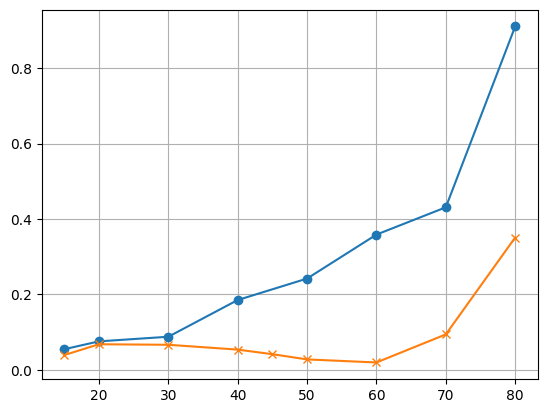

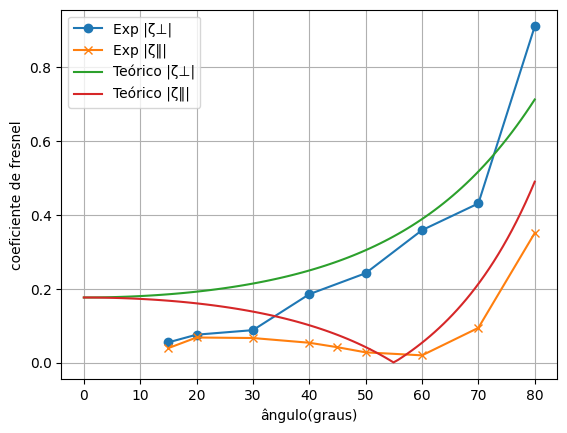

In [ ]:
# Contas Luiza e Henrique
I01 = 35
I1 = [0.105 , 0.2 , 0.27 , 1.2 , 2.05 , 4.5 , 6.5 , 29]
alpha1 = [15 , 20 , 30 , 40 , 50 , 60 , 70, 80]

I02 = 26
I2 = [0.04 , 0.12 , 0.115 , 0.075 , 0.045 , 0.02 , 0.01 , 0.23 , 3.2]
alpha2 = [15 , 20 , 30 , 40 , 45 , 50 , 60 , 70 , 80]

chi1 = lista_coeficiente(I01, I1)

chi2 = lista_coeficiente(I02, I2)

plot1(alpha1, chi1, alpha2, chi2)

#determinar o n aqui

n = 1.428

plotfinal(alpha1, chi1, alpha2, chi2, n)

# Experimento 8 : Birrefringência

In [ ]:
theta1 =  [4, 14, 24, 34, 44, 54, 64, 74, 84, 94]#graus
theta2 = [0, 22, 42, 62, 89, 117, 134, 154, 170, 184] #graus

In [ ]:
def Grafico_Theta(theta1, theta2):
  regressao = cp.stats.linregress(theta1, theta2)
  slope = regressao.slope
  intercept = regressao.intercept
  rvalue = regressao.rvalue
  pvalue = regressao.pvalue
  stderr = regressao.stderr
  intercept_stderr = regressao.intercept_stderr
  texto = (
    f'Ajuste Linear: Ax+b = y\n'
    f'A = {slope:.3f} +/- {stderr:.3f}\n'
    f'b = {intercept:.3f} +/- {intercept_stderr:.3f}'
  )
  plt.scatter(theta1, theta2, marker='o', label='Dados experimentais')
  plt.plot(theta1, [intercept + slope * x for x in theta1], 'r', label='ajuste linear')
  plt.xlabel("θ₁")
  plt.ylabel("θ₂")
  plt.title("θ₁ x θ₂")
  plt.text(0.05, 0.95, texto, fontsize=10, bbox=dict(boxstyle='round', fc='lightblue', ec='black', alpha=0.5),transform=plt.gca().transAxes, va='top')
  plt.grid(True)
  plt.legend()
  plt.show()

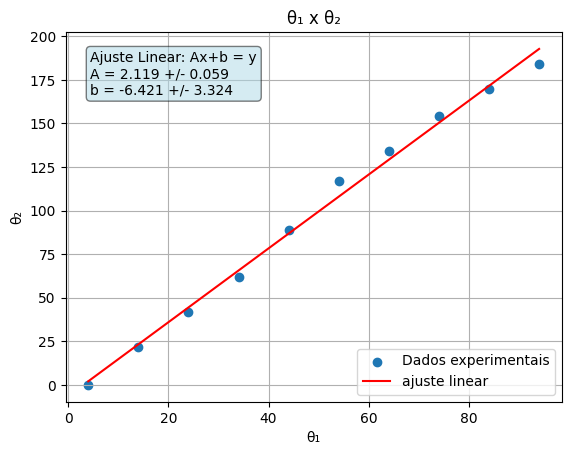

In [ ]:
Grafico_Theta(theta1, theta2)

In [ ]:
#determine as direções dos eixos ópticos do bloco de acrílico --- Não conseguimos devido ao acrílico usado ....

In [ ]:
minimos = [4.2, 8.1, 12.2, 16.4, 20.2, 24, 20.3, 31.4, 36.4, 40.9, 45.4 ]

In [ ]:
def Calcula_birrefringencia(minimos):
  comprimento_onda = 632.8  * 10**(-9) #m
  dif_fase = 2 * np.pi
  d = (minimos[len(minimos)- 1]*10**(-2) - minimos[0]*10**(-2))/ len(minimos)
  birrefringencia = dif_fase * comprimento_onda/(2 * np.pi * d)
  return birrefringencia,d


In [ ]:
birefringencia = Calcula_birrefringencia(minimos)
print("birrefringencia do acrilico:", birefringencia)

birrefringencia do acrilico: (1.6895145631067962e-05, 0.037454545454545456)


In [ ]:
dic_variaveis = {"c" : 632.8 * 10**(-9), "dif": 2 * np.pi , "d" : 0.0374}
dic_incerteza = {"c" : 0 , "dif": 0 , "d" : 0.005}
comprimento_onda = 632.8  * 10**(-9) #m
dif_fase = 2 * np.pi
d = 0.0374
eq = "birrefringencia = dif * c/(2 * pi * d)"

incerteza_variavel_equacao(eq, dic_variaveis, dic_incerteza, "birrefringencia")

Questão P1:

In [ ]:
def E_final_X(theta, fase, t):
  E = 100
  z = 0
  comprimento_onda = 632.8 * 10**(-9)
  k = 2 * np.pi / comprimento_onda
  c = 3e8
  f = c / comprimento_onda
  omega = 2 * np.pi * f

  EF = E *(np.sin(theta)* np.cos(k*z - omega * t))
  return EF

def E_final_Y(theta, fase, t):
  E = 100
  z = 0
  comprimento_onda = 632.8 * 10**(-9)
  k = 2 * np.pi / comprimento_onda
  c = 3e8  # velocidade da luz em m/s
  f = c / comprimento_onda  # frequência
  omega = 2 * np.pi * f

  EF = E *(np.cos(theta)* np.cos(k*z - omega*t + fase))
  return EF

def imagem_E_final(angulo, fase):
  #titulo = "Trajetória r'$\vec{E}$': " + "θ = " + str(angulo) + "°, " + "δ = " + str(fase) + "°"
  fase_g = np.degrees(fase)
  titulo = (r"Trajetória $\vec{E}$: " +
              r"$\theta = {}^\circ$, ".format(angulo) +
              r"$\delta = {}^\circ$".format(fase_g))

  angulo = np.radians(angulo)

  comprimento_onda = 632.8e-9
  c = 3e8
  f = c / comprimento_onda
  T = 1 / f
  tempo = np.linspace(0, 5*T, 1000)

  EX = []
  EY = []

  for i in range(len(tempo)):
    EX.append(E_final_X(angulo, fase, tempo[i]))
    EY.append(E_final_Y(angulo, fase, tempo[i]))

  plt.plot(EX, EY)
  plt.xlabel(r'$E_x$')
  plt.ylabel(r'$E_y$')
  plt.title(titulo)
  plt.axis('equal')
  plt.grid()
  plt.show()


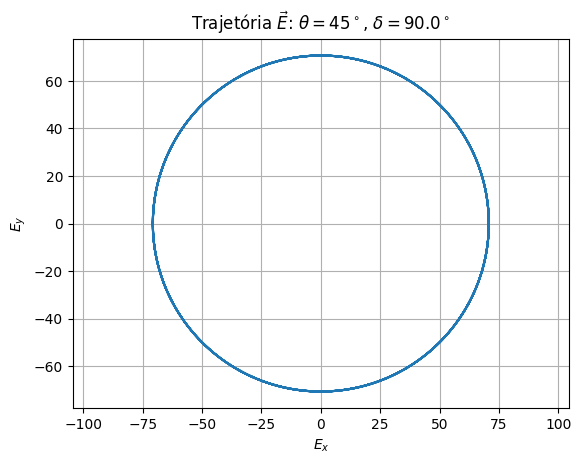

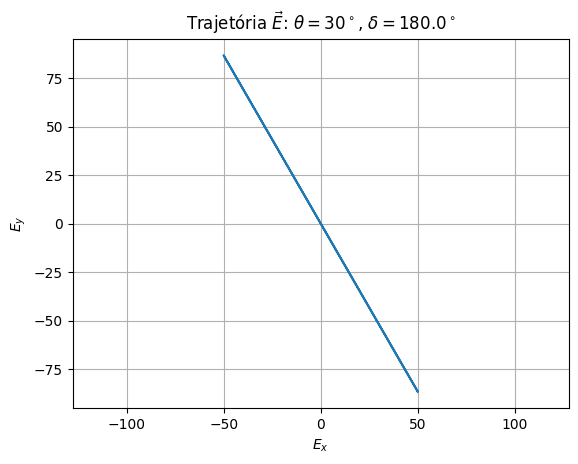

In [ ]:
imagem_E_final(45, np.pi/2)
imagem_E_final(30, np.pi)


# Experimento 9

In [ ]:
def Corrige_angulo(lista_angulos, angulo_zero):
  angulo_corrigido=[]

  for i in range (len(lista_angulos)):
    angulo_corrigido.append(lista_angulos[i] - angulo_zero)

  return angulo_corrigido

In [ ]:
def atividade_otica(concentracao, angulos, distancias):
  #arrumar o angulo de acordo com o angulo em que o laser some sem a solução
  titulo_g = "Gráfico para concentração de " + concentracao + "% de açucar"

  result  = cp.stats.linregress(distancias, angulos)
  slope, intercept, r, p, stderr = result
  intercept_stderr = result.intercept_stderr
  texto = (
    f'Ajuste Linear: Ax+b = y\n'
    f'A = {slope:.3f} +/- {stderr:.3f}\n'
    f'b = {intercept:.3f} +/- {intercept_stderr:.3f}')
  plt.plot(distancias, angulos, 'o', label='Medidas experimentais')
  plt.plot(distancias, [intercept + slope * x for x in distancias], 'r', label='ajuste linear')

  #arrumar o titulo para a concentração certa
  plt.title(titulo_g)
  plt.ylabel("Ângulo de plano de polarização (em graus)")
  plt.xlabel("Distância (cm)")
  plt.text(0.05, 0.95, texto, fontsize=10, bbox=dict(boxstyle='round', fc='lightblue', ec='black', alpha=0.5),transform=plt.gca().transAxes, va='top')
  plt.grid()
  plt.legend()
  plt.show()

  return (slope, stderr)


In [ ]:
def Calcula_poder_rotatorio(p, c):
  return p/c

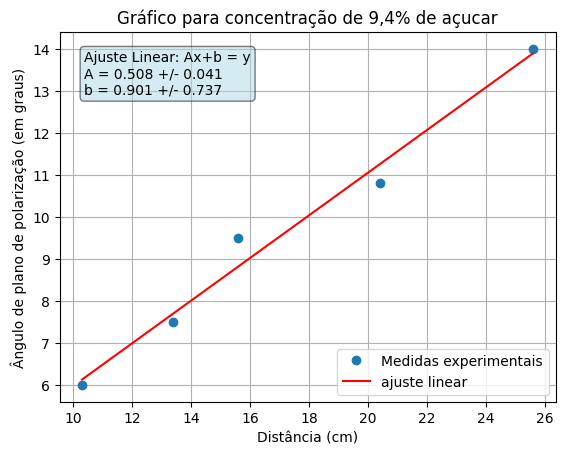

Poder Rotatório:  0.0539938714408205


In [ ]:
#Distancia = [21.5, 16.5, 13.5, 10.5]
#Angulo = [144, 150, 154.5,16]

Distancia = [10.3, 13.4, 15.6, 20.4, 25.6]
Angulo = [15, 16.5, 18.5, 19.8, 23]
Angulo = Corrige_angulo(Angulo, 9)
slope, erro_slope = (atividade_otica("9,4" ,Angulo, Distancia))
p_r = Calcula_poder_rotatorio(slope,9.4)
print("Poder Rotatório: ", p_r)
#n = 1.347

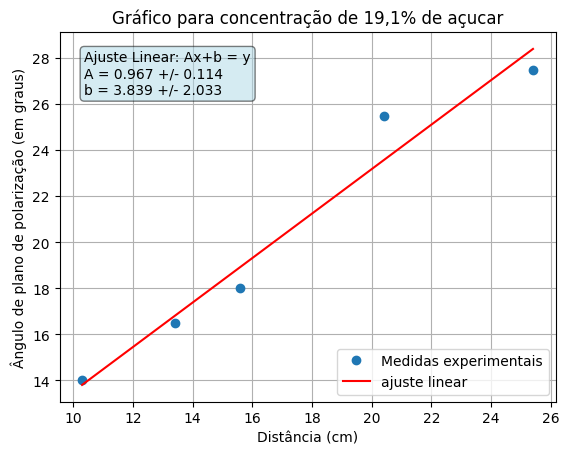

Poder Rotatório:  0.05063772472496195


In [ ]:
Distancia = [10.3, 13.4, 15.6, 20.4, 25.4]
Angulo = [23, 25.5, 27, 34.5, 36.5]
Angulo = Corrige_angulo(Angulo, 9)
slope, erro_slope = (atividade_otica("19,1" ,Angulo, Distancia))
p_r = Calcula_poder_rotatorio(slope, 19.1)
print("Poder Rotatório: ", p_r)
#n = 1.3625

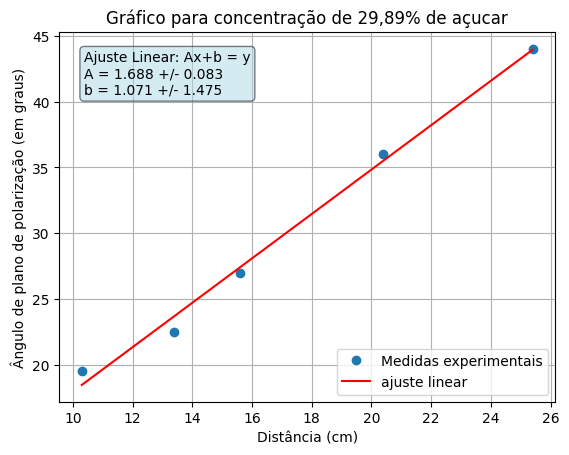

Poder Rotatório:  0.058427433279075854


In [ ]:
Distancia = [10.3, 13.4, 15.6, 20.4, 25.4]
Angulo = [29, 32, 36.5, 45.5, 53.5]
Angulo = Corrige_angulo(Angulo, 9.5)
slope, erro_slope = atividade_otica("29,89" ,Angulo, Distancia)
p_r = Calcula_poder_rotatorio(slope,28.89)
print("Poder Rotatório: ", p_r)
#n = 1.305

In [ ]:
#10: 0,71 (0,06)
#20: 1,6 (0,2)
#30: 1,6 (0,4)


# Experimento 10

In [ ]:
#Deveriamos multiplicar os x por 2 pois o caminho é de ida e volta?

x_1 = [147, 146.8, 146.3, 146.5, 147.2, 146.2] #cm
x_2 = [127.25, 127, 125.6, 126.25, 126.1, 126] #cm
freq = 50,1 *10**6

for i in range(len(x_1)):
  x_1[i] = x_1[i] * 10**(-2) #m
  x_2[i] = x_2[i] * 10**(-2) #m

#Os valores ainda não são os dados, só estou montando as contas

In [ ]:
media1 , desvio1   = Erro_padra(x_1)
media2, desvio2 = Erro_padra(x_2)
print("A média de x1 é", media1 , "e o erro padrão é", desvio1)
print("A média de x2 é", media2 , "e o erro padrão é", desvio2)

A média de x1 é 1.4666666666666666 e o erro padrão é 0.0016261747890200578
A média de x2 é 1.2636666666666667 e o erro padrão é 0.0025744470819532845


In [ ]:
#velocidade da luz no ar
c_ar = 4 * freq * media1
print("A velocidade na luz no ar é", c_ar, "m/s")

TypeError: can't multiply sequence by non-int of type 'float'

In [ ]:
#velocidade da luz na água
l_m = 0,95
delta_x = 1.4666666666666666 - 1.2636666666666667
n = (2*delta_x)/l_m + 1

TypeError: unsupported operand type(s) for /: 'float' and 'tuple'